In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/Clean_Weather.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1091 entries, 0 to 1090
Data columns (total 25 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Tahun       1091 non-null   int64
 1   Bulan       1091 non-null   int64
 2   tgl         1091 non-null   str  
 3   temp7       1091 non-null   str  
 4   temp13      1091 non-null   str  
 5   temp18      1091 non-null   str  
 6   temp_avg    1091 non-null   str  
 7   temp_24     1091 non-null   str  
 8   temp_max    1091 non-null   str  
 9   temp_min    1091 non-null   str  
 10  CH          1091 non-null   str  
 11  light_hour  1091 non-null   str  
 12  light_per   1091 non-null   str  
 13  pck         1061 non-null   str  
 14  tgl.1       1091 non-null   str  
 15  press       1091 non-null   str  
 16  humid7      1091 non-null   str  
 17  humid13     1091 non-null   str  
 18  humid18     1091 non-null   str  
 19  humid_avg   1091 non-null   str  
 20  humid_24    1091 non-null   str  
 21  ws

In [5]:
df.describe()

,Tahun,Bulan
count,1091.000000,1091.000000
mean,2020.000917,6.519707
std,0.818927,3.454332
min,2019.000000,1.000000
25%,2019.000000,4.000000
50%,2020.000000,7.000000
75%,2021.000000,10.000000
max,2021.000000,12.000000


In [6]:
df.isnull().sum()

Tahun          0
Bulan          0
tgl            0
temp7          0
temp13         0
temp18         0
temp_avg       0
temp_24        0
temp_max       0
temp_min       0
CH             0
light_hour     0
light_per      0
pck           30
tgl.1          0
press          0
humid7         0
humid13        0
humid18        0
humid_avg      0
humid_24       0
ws_abg         0
mod_dir        0
max_ws         0
dir            0
dtype: int64

In [7]:
df.shape

(1091, 25)

In [8]:
df.columns

Index(['Tahun', 'Bulan', 'tgl', 'temp7', 'temp13', 'temp18', 'temp_avg',
       'temp_24', 'temp_max', 'temp_min', 'CH', 'light_hour', 'light_per',
       'pck', 'tgl.1', 'press', 'humid7', 'humid13', 'humid18', 'humid_avg',
       'humid_24', 'ws_abg', 'mod_dir', 'max_ws', 'dir'],
      dtype='str')

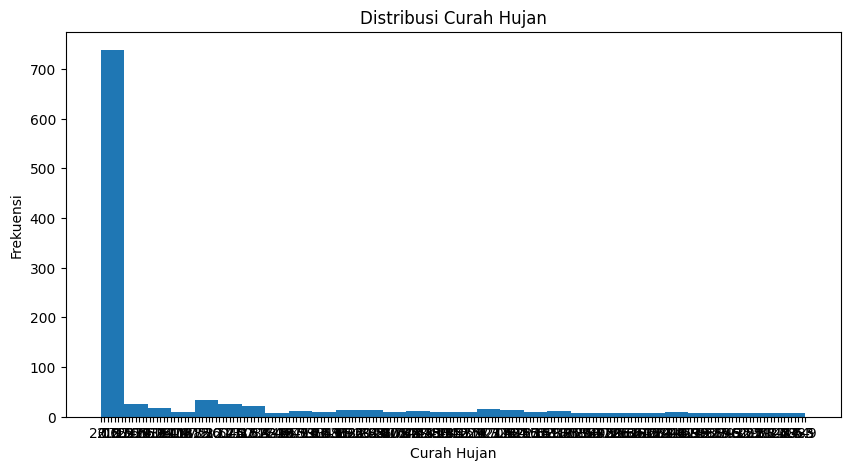

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df['CH'], bins=30)

plt.title('Distribusi Curah Hujan')
plt.xlabel('Curah Hujan')
plt.ylabel('Frekuensi')

plt.show()

In [13]:
df['CH'].dtype

<StringDtype(na_value=nan)>

In [14]:
df['CH'] = pd.to_numeric(df['CH'], errors='coerce')

In [15]:
df['CH'].dtype

dtype('float64')

In [16]:
df['CH'].isnull().sum()

np.int64(731)

In [17]:
df = df.dropna()

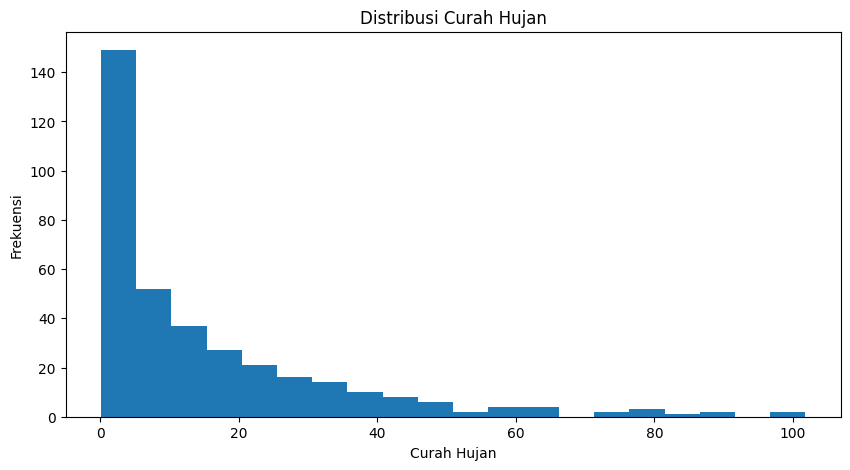

In [18]:
plt.figure(figsize=(10,5))

plt.hist(df['CH'], bins=20)

plt.title('Distribusi Curah Hujan')
plt.xlabel('Curah Hujan')
plt.ylabel('Frekuensi')

plt.show()

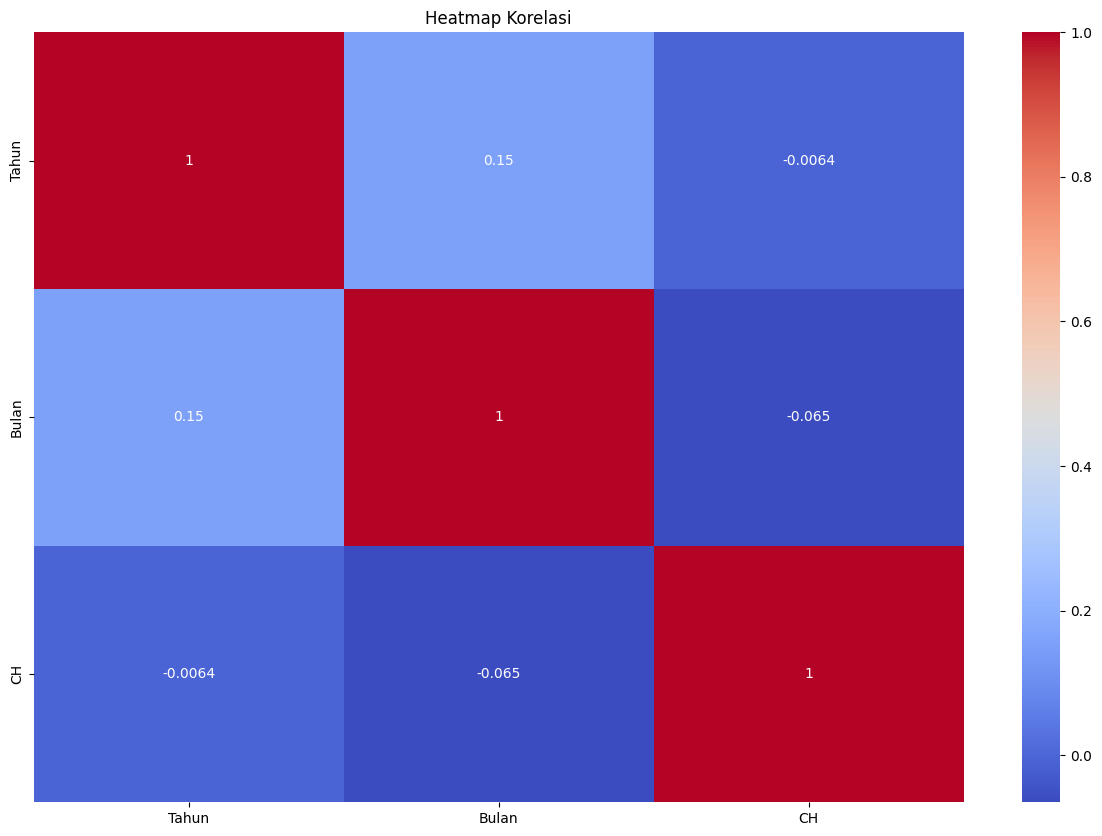

In [19]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Heatmap Korelasi')

plt.show()

In [20]:
X = df[['temp_avg',
        'temp_max',
        'temp_min',
        'press',
        'humid_avg',
        'ws_abg',
        'max_ws',
        'light_hour']]

y = df['CH']

In [21]:
X.shape

(360, 8)

In [22]:
y.shape

(360,)

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(288, 8)
(72, 8)


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler = StandardScaler()

In [29]:
X_train = scaler.fit_transform(X_train)

In [30]:
X_test = scaler.transform(X_test)

In [31]:
X_train[:5]

array([[ 0.49103782,  1.11531289, -0.19089103, -2.74491447, -0.61722154,
         0.23302291, -0.38841937,  1.43051962],
       [-0.27635152, -0.33779777, -0.71076446, -0.34266344,  0.31835637,
         0.75011063,  0.15461354, -0.90192043],
       [-1.48224905, -1.06435311, -0.32085939, -1.96580603,  2.18951221,
        -0.61647834,  0.15461354, -1.57473967],
       [ 1.14880011,  0.75203523,  1.49869764,  0.89092493, -2.02058842,
         0.23302291, -0.93145228,  1.34081039],
       [-0.60523266, -0.19248671, -0.71076446,  0.3715193 ,  0.0844619 ,
        -0.8750222 , -0.38841937, -0.04968272]])

In [32]:
from sklearn.linear_model import LinearRegression

In [33]:
lr_model = LinearRegression()

In [34]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [35]:
y_pred_lr = lr_model.predict(X_test)

In [36]:
y_pred_lr[:10]

array([18.76869984, 20.54016132, 10.45811247,  8.11425264, 16.65918498,
       28.47719391,  9.50062458, 20.36012044, 10.68044788, 16.97085135])

In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [38]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("MAE:", mae_lr)

MAE: 14.706708767281002


In [39]:
r2_lr = r2_score(y_test, y_pred_lr)

print("R2 Score:", r2_lr)

R2 Score: 0.00655841749776731


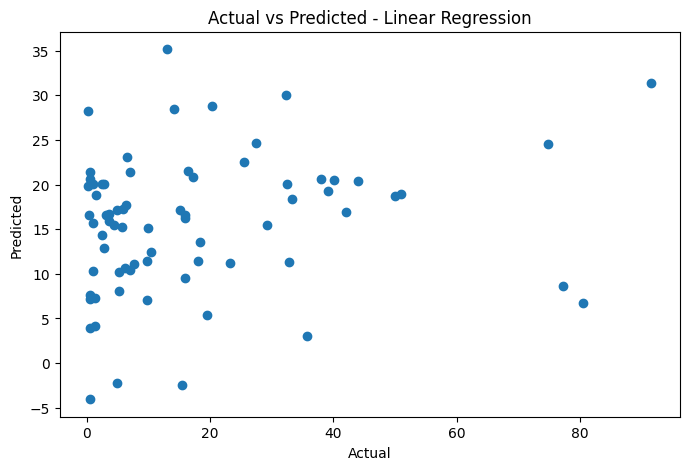

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted - Linear Regression")

plt.show()

In [43]:
joblib.dump(lr_model, '../models/linear_regression.pkl')

['../models/linear_regression.pkl']

In [44]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [45]:
ann_model = Sequential()

In [46]:
ann_model.add(Dense(64, activation='relu', input_shape=(8,)))

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
ann_model.add(Dense(32, activation='relu'))

In [48]:
ann_model.add(Dense(1))

In [49]:
ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [50]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = ann_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 452.6999 - mae: 13.3599 - val_loss: 888.7307 - val_mae: 18.5544
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 432.9228 - mae: 12.7437 - val_loss: 860.7981 - val_mae: 18.0134
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 414.2763 - mae: 12.2447 - val_loss: 828.1202 - val_mae: 17.5561
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 391.4772 - mae: 11.8323 - val_loss: 790.3115 - val_mae: 17.1499
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 368.3195 - mae: 11.4677 - val_loss: 743.8539 - val_mae: 16.7309
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 342.4973 - mae: 11.1735 - val_loss: 696.2369 - val_mae: 16.3828
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 320.8055 - mae: 11.0259 - val_loss: 647.0336 - val_mae: 16.0806
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 301.5336 - mae: 10.9216 - val_loss: 608.3734 - val_mae: 15.8459
Epoch 9/100
15/

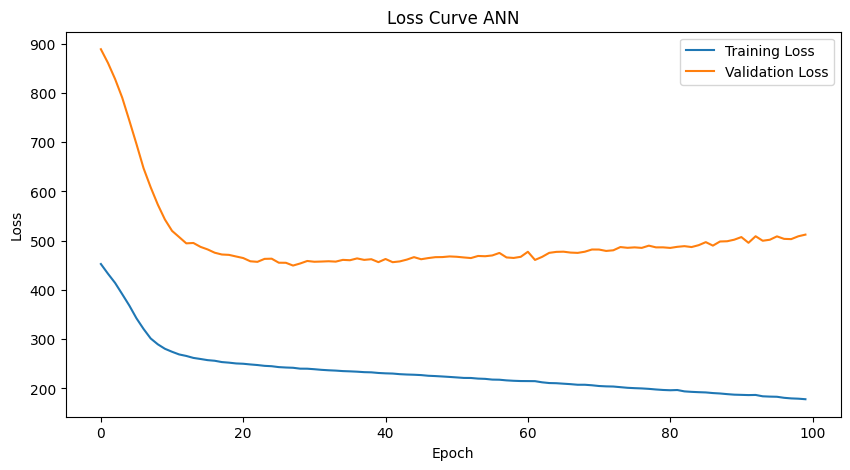

In [52]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve ANN')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [53]:
y_pred_ann = ann_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [54]:
y_pred_ann[:10]

array([[21.32454  ],
       [13.893887 ],
       [10.528437 ],
       [ 7.3868775],
       [ 5.5153766],
       [28.912031 ],
       [ 5.6657166],
       [23.43229  ],
       [ 8.985368 ],
       [14.224129 ]], dtype=float32)

In [55]:
y_pred_ann = y_pred_ann.flatten()

In [56]:
mae_ann = mean_absolute_error(y_test, y_pred_ann)

print("MAE ANN:", mae_ann)

MAE ANN: 13.813673061794704


In [57]:
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))

print("RMSE ANN:", rmse_ann)

RMSE ANN: 19.80600311344506


In [58]:
r2_ann = r2_score(y_test, y_pred_ann)

print("R2 ANN:", r2_ann)

R2 ANN: 0.07413721319778166


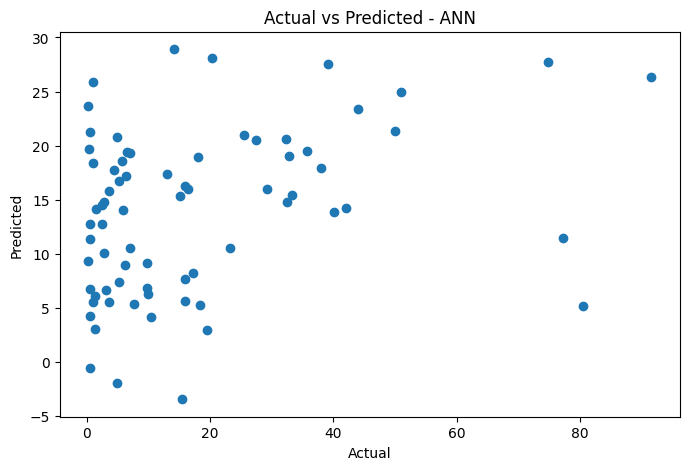

In [59]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_ann)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted - ANN")

plt.show()

In [60]:
ann_model.save('../models/ann_model.h5')

In [61]:
from tensorflow.keras.layers import LSTM

In [63]:
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

In [64]:
X_test_lstm = X_test.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)

In [65]:
print(X_train_lstm.shape)
print(X_test_lstm.shape)

(288, 1, 8)
(72, 1, 8)


In [66]:
lstm_model = Sequential()

In [67]:
lstm_model.add(
    LSTM(
        64,
        activation='tanh',
        input_shape=(1, 8)
    )
)

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
lstm_model.add(Dense(1))

In [69]:
lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [70]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,753 (73.25 KB)

 Trainable params: 18,753 (73.25 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 455.2214 - mae: 13.4988 - val_loss: 905.1713 - val_mae: 19.0501
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 452.8965 - mae: 13.4255 - val_loss: 901.2980 - val_mae: 18.9751
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 450.5031 - mae: 13.3471 - val_loss: 897.3031 - val_mae: 18.8951
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 447.9520 - mae: 13.2582 - val_loss: 892.2814 - val_mae: 18.8050
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 444.5656 - mae: 13.1578 - val_loss: 886.6720 - val_mae: 18.7075
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 440.8571 - mae: 13.0423 - val_loss: 879.7360 - val_mae: 18.5879
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 436.1548 - mae: 12.9024 - val_loss: 871.1611 - val_mae: 18.4455
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 430.5310 - mae: 12.7405 - val_loss: 861.1981 - val_mae: 18.2769
Epoch 9/100
15/

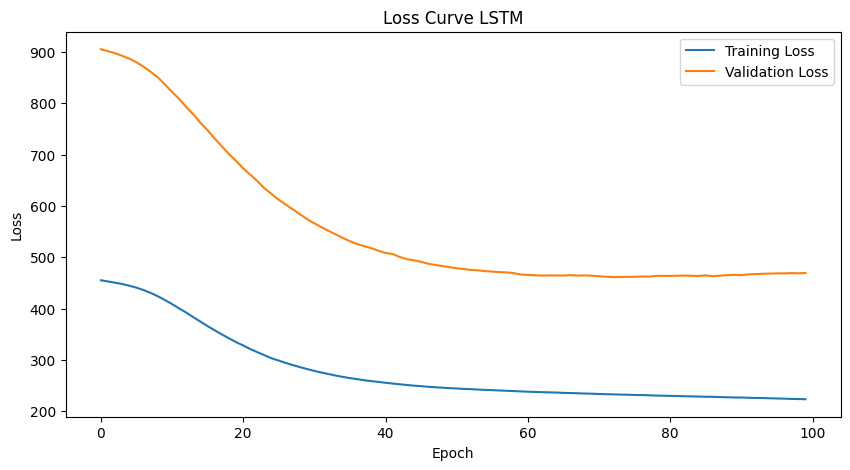

In [72]:
plt.figure(figsize=(10,5))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve LSTM')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [73]:
y_pred_lstm = lstm_model.predict(X_test_lstm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [74]:
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)

print("MAE LSTM:", mae_lstm)

MAE LSTM: 13.6169421699312


In [75]:
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print("RMSE LSTM:", rmse_lstm)

RMSE LSTM: 19.76998844756607


In [76]:
r2_lstm = r2_score(y_test, y_pred_lstm)

print("R2 LSTM:", r2_lstm)

R2 LSTM: 0.0775012763315619


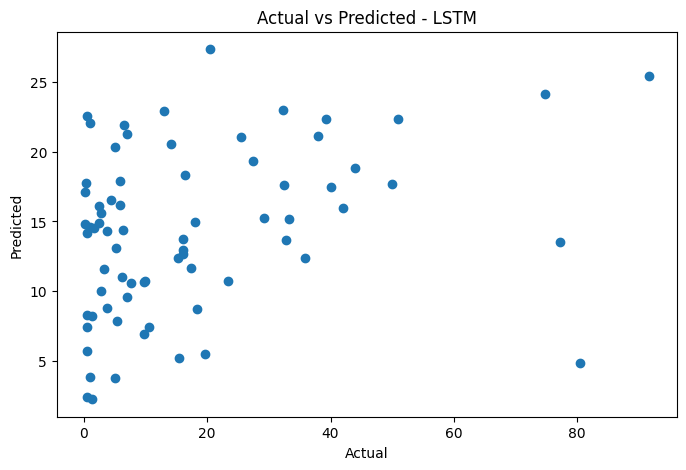

In [77]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lstm)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted - LSTM")

plt.show()

In [78]:
lstm_model.save('../models/lstm_model.h5')

In [79]:
from sklearn.cluster import KMeans

In [80]:
X_cluster = df[[
    'temp_avg',
    'humid_avg',
    'press',
    'ws_abg'
]]

In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

In [83]:
inertia = []

In [84]:
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inertia.append(kmeans.inertia_)

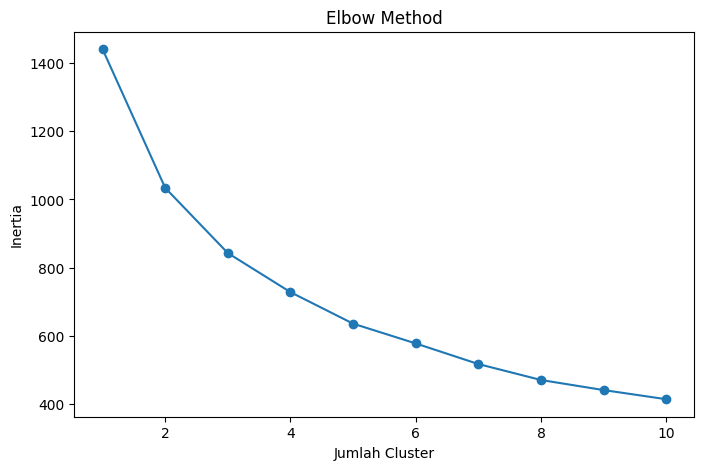

In [85]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')

plt.show()

In [87]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [88]:
kmeans.fit(X_cluster_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [89]:
clusters = kmeans.labels_

clusters[:10]

array([0, 0, 2, 2, 2, 2, 1, 0, 0, 0], dtype=int32)

In [90]:
df['Cluster'] = clusters

In [91]:
df['Cluster'].value_counts()

Cluster
2    140
0    138
1     82
Name: count, dtype: int64

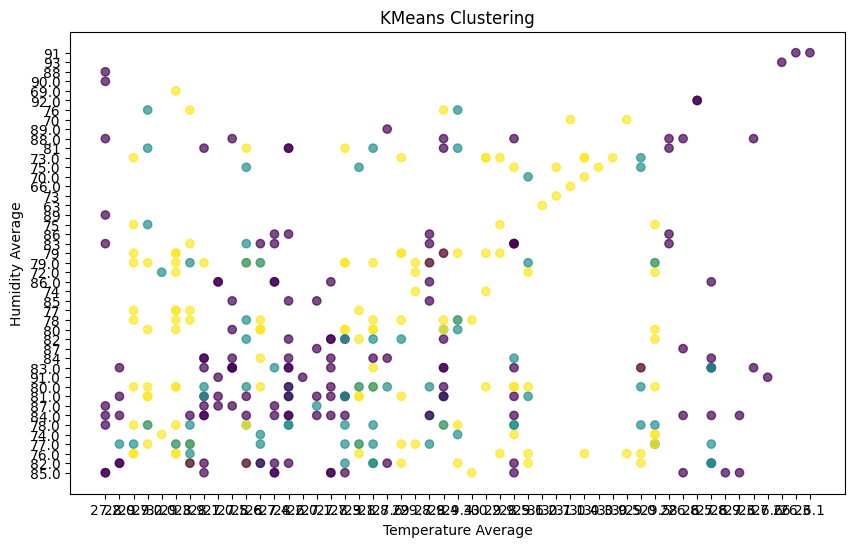

In [96]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['temp_avg'],
    df['humid_avg'],
    c=df['Cluster'],
    alpha=0.7
)

plt.xlabel('Temperature Average')
plt.ylabel('Humidity Average')

plt.title('KMeans Clustering')

plt.show()

In [93]:
joblib.dump(kmeans, '../models/kmeans_model.pkl')

['../models/kmeans_model.pkl']

In [97]:
from sklearn.metrics import mean_absolute_percentage_error

In [98]:
mape_lstm = mean_absolute_percentage_error(
    y_test,
    y_pred_lstm
)

print("MAPE LSTM:", mape_lstm)

MAPE LSTM: 5.94266102928573


In [99]:
from sklearn.metrics import silhouette_score

In [100]:
sil_score = silhouette_score(
    X_cluster_scaled,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.23777840329431574


In [101]:
bp_model = Sequential()

In [102]:
bp_model.add(
    Dense(
        128,
        activation='relu',
        input_shape=(8,)
    )
)

c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [103]:
bp_model.add(Dense(64, activation='relu'))

In [104]:
bp_model.add(Dense(32, activation='relu'))

In [105]:
bp_model.add(Dense(1))

In [106]:
bp_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [107]:
bp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [108]:
history_bp = bp_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 445.8034 - mae: 13.1784 - val_loss: 870.0754 - val_mae: 18.2409
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 412.3911 - mae: 12.1856 - val_loss: 804.7902 - val_mae: 17.1673
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 357.4780 - mae: 11.2116 - val_loss: 692.7957 - val_mae: 16.2864
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 305.3713 - mae: 11.3870 - val_loss: 576.6246 - val_mae: 15.8872
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 284.1974 - mae: 11.7447 - val_loss: 541.8898 - val_mae: 15.4878
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 275.7276 - mae: 11.6957 - val_loss: 513.4232 - val_mae: 15.2883
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 267.4746 - mae: 11.3094 - val_loss: 508.1084 - val_mae: 14.9568
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 262.9794 - mae: 11.1122 - val_loss: 484.4013 - val_mae: 14.7495
Epoch 9/150
15/

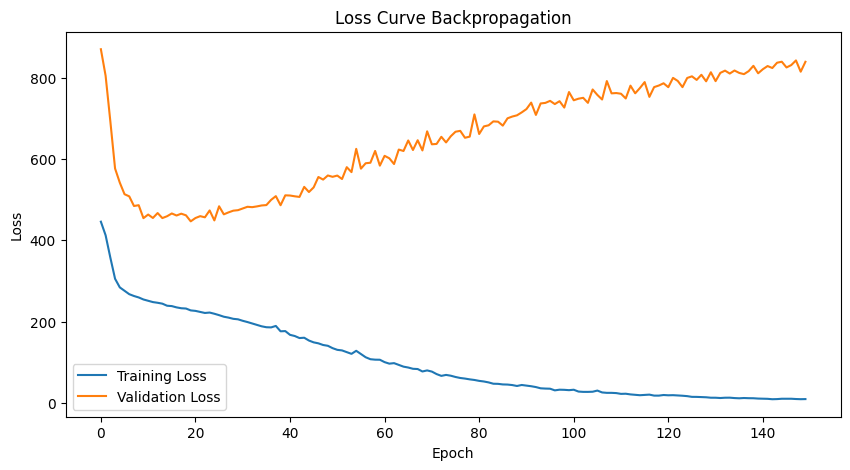

In [109]:
plt.figure(figsize=(10,5))

plt.plot(
    history_bp.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_bp.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss Curve Backpropagation')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [110]:
y_pred_bp = bp_model.predict(X_test)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000029DBABD7560> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [111]:
y_pred_bp = y_pred_bp.flatten()

In [112]:
mae_bp = mean_absolute_error(
    y_test,
    y_pred_bp
)

print("MAE Backpropagation:", mae_bp)

MAE Backpropagation: 16.641990124351448


In [113]:
rmse_bp = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_bp
    )
)

print("RMSE Backpropagation:", rmse_bp)

RMSE Backpropagation: 24.504605207752014


In [114]:
r2_bp = r2_score(
    y_test,
    y_pred_bp
)

print("R2 Backpropagation:", r2_bp)

R2 Backpropagation: -0.41725619137112235


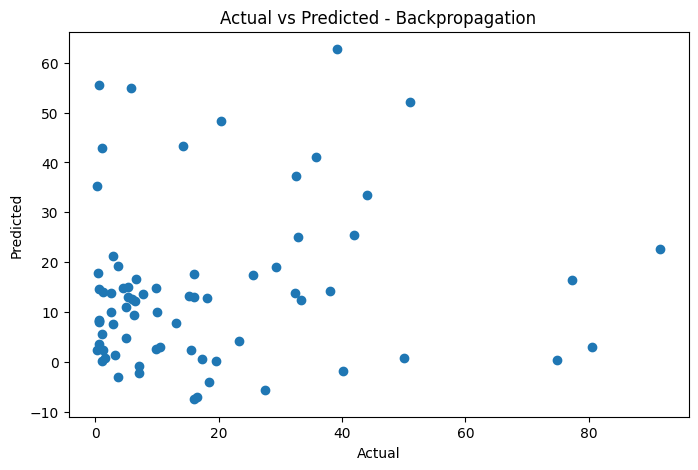

In [115]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_bp
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted - Backpropagation")

plt.show()

In [116]:
bp_model.save('../models/backpropagation_model.h5')